# Binary CLASSIFICATION

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

""" DataFrames aren't ideal for the MNIST image dataset so we want to get the data as numpy arrays
    set as_frame=false
"""
mnist=fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
X,y =  mnist['data'], mnist['target']
X.shape, y.shape

((70000, 784), (70000,))

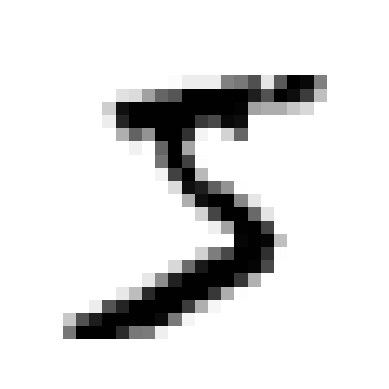

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image= image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    #plt.figure(figsize=(0.01,0.01))
    
some_digit=X[0]
plot_digit(some_digit)
plt.show()

In [33]:
y[0]

'5'

In [8]:
#The labels are strings. Cast to integer to make easier to use in ML algorithm
y=y.astype(np.uint8)

In [9]:
#Dataset is already shuffled so all cross validation folds will not be missing some digits
X_train, X_test, y_train, y_test = X[:60_000], X[60_000:], y[:60_000], y[60_000:]

In [10]:
# 5-detector
y_train_5 = (y_train == 5)
y_test_5 = (y_test ==5)

In [11]:
((y_train_5 == True).sum())/len(y_train)

np.float64(0.09035)

#### Stochastic Gradient Descent (SGD)

In [12]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [13]:
sgd_clf.predict([some_digit])

array([ True])

### Measuring Accuracy

In [14]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [51]:
from sklearn.dummy import DummyClassifier

#The dummy classifier just  classifies every image in the most frequently occuring class

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))   #prints False i.e no 5s

cross_val_score(dummy_clf, X_train, y_train_5, cv=4, scoring="accuracy")

False


array([0.9096    , 0.90966667, 0.90966667, 0.90966667])

<u>Interpretation</u>: If you guess the number will not be 5 you will be right about 90% of the time

#### Confusion matrix

In [15]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)   #unlike cross_val_score returns predictions instead of evaluation scores

from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [16]:
import pandas as pd
pd.DataFrame(cm, columns=["Not 5","5"], index=["Not 5", "5"])

,Not 5,5
Not 5,53892,687
5,1891,3530


In [17]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

#### Precision, Recall/Sensitivity/(TPR)
***Precision*** - Correct identification (low false positive)  
***Recall*** - not missing (low false negative) OR the true positive rate  

***Specificity*** - the TNR -True negative rate aka the ratio of negative instances correctly classified as negative

```python
precision_score( y, y_pred)  
recall_score (y, y_pred)  
f1_score(y, y_pred)
precision_recall_curve(y, y_scores)  #precision/recall pairs for each threshold  
roc_curve(y, y_scores)     #fpr, tpr (recall) pairs for for each threshold
```



In [18]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_5, y_train_pred))
print(recall_score(y_train_5, y_train_pred))

0.8370879772350012
0.6511713705958311


F1 score calculates the harmonic mean of precision and recall.  
Use F1 score when the binary classes are unevenly distributed e.g  
where the majority of cases is negative but we want to detect the rare  
positive cases so a high __accuracy__ score is misleading or useless

In [19]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [20]:
#decision_function() returns a score instead of a prediction
y_score = sgd_clf.decision_function([some_digit])
y_score


array([2164.22030239])

In [22]:
threshold = 0
y_some_digit_pred = (y_score > threshold)
y_some_digit_pred

array([ True])

The SGD classifier misses the 5 when the threshold is raised i.e decreases recall

In [23]:
threshold=3000
y_some_digit_pred = (y_score > threshold)
y_some_digit_pred

array([False])

__Deciding which Threshold to use__

In [24]:
#Get all the cross validation scores
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

#compute precision and recall for all possible thresholds

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)



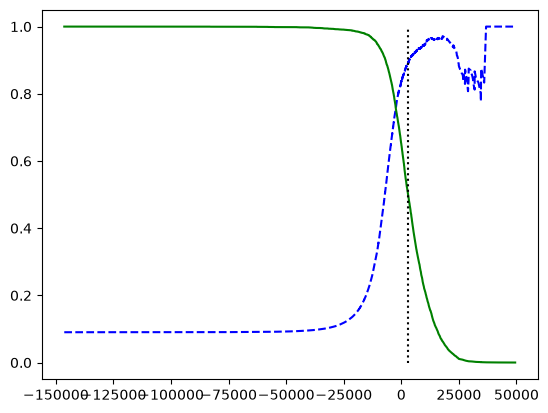

In [25]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.vlines(threshold,0,1.0, "k", "dotted", label="threshold")
    [...]  #?

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

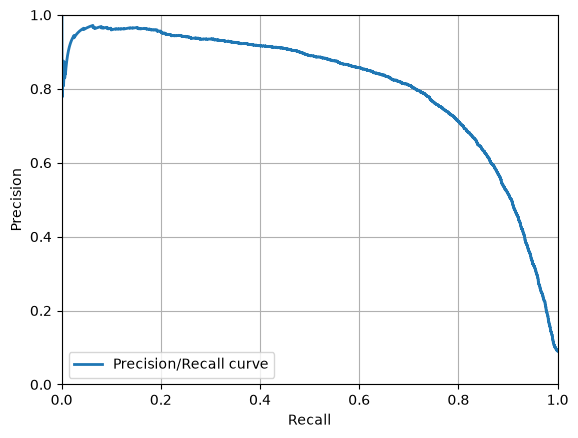

In [26]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.grid()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0,1,0,1])
plt.legend(loc="lower left")
plt.show()

In [27]:
from sklearn.metrics import average_precision_score
pr_auc_score = average_precision_score(y_train_5, y_scores)
pr_auc_score

0.8100417627526459

In [28]:
#search for the lowest threshold with precision > 90%

threshold_90_precision = thresholds[np.argmax(precisions >=0.9)]  #np.argmax(precisions >=0.9) returns the position of the first True
threshold_90_precision

np.float64(3370.0194991439557)

In [29]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
y_train_pred_90

array([False, False, False, ...,  True, False, False], shape=(60000,))

In [31]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [32]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

The threshold that gives us 90% precision give us 47% recall i.e when it identifies a number ad 5, nine times out of 10
it is correct, but it only identifies a correct 5 47% of the time


#### ROC Curve (Reciever operating charecteristic curve)
Plots sensitivity (recall) vs 1 - specificity

In [89]:
y_train_5

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
idx_for_threshold_90 = (thresholds <= threshold_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_90], fpr[idx_for_threshold_90]


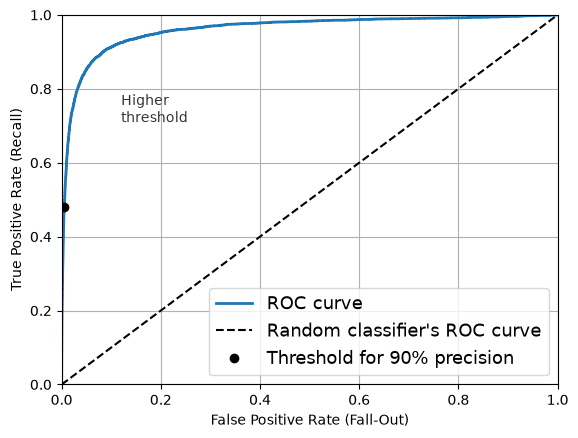

In [34]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
    plt.plot([0,1],[0,1], 'k--', label="Random classifier's ROC curve")
    plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

    plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
    plt.xlabel('False Positive Rate (Fall-Out)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.grid()
    plt.axis([0, 1, 0, 1])
    plt.legend(loc="lower right", fontsize=13)

plot_roc_curve(fpr,tpr)

One way to measure how good a classifier is is to measure the area under the curve (AUC). 
A perfect classfier (no False positives) will have an area = 1

In [35]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

__Discussion__:
ROC vs PR curve: Use the PR curve whenever the positive class is rare or you care more about the false positives than negatives  
Use the ROC curve otherwise. In the example above the ROC is pretty good but that is because there are few positives (5s) compared to negatives  
(not 5s). The PR curve actually shows the classifier has room for improvement (compare roc_auc_score vs pr_auc_score)

### Random Forest Classifier
Let's compare a Random Forest classifier to the SGD classifier

In [36]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba") 

#predict_proba returns prediction probabilities for positive and negative

In [37]:
y_probas_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]], shape=(60000, 2))

In [40]:
# We'll us the positive class probability as the score to calculate PR and ROC curves
y_scores_forest = y_probas_forest[:,1] 
precisions_forest, recalls_forest, threshold_forest = precision_recall_curve(y_train_5, y_scores_forest)
fpr_forest, tpr_forest, thresholds_forest =roc_curve(y_train_5, y_scores_forest)

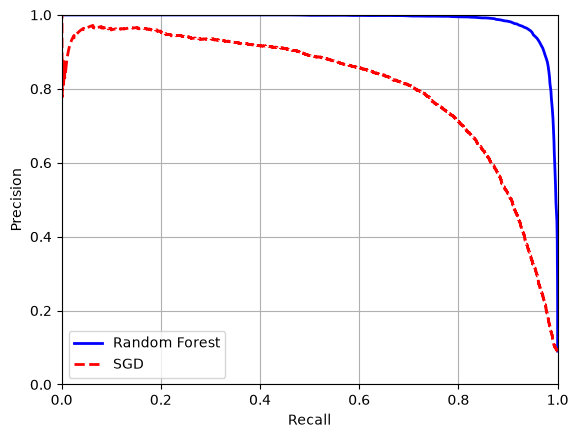

In [41]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "r--", linewidth=2, label="SGD")
plt.grid()

plt.xlabel("Recall")
plt.ylabel("Precision")


plt.axis([0,1,0,1])
plt.legend(loc="lower left")
plt.show()



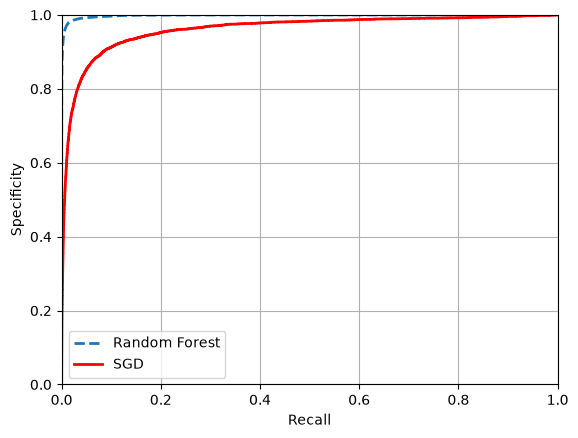

In [42]:
plt.plot(fpr_forest, tpr_forest, "--", linewidth=2, label="Random Forest")
plt.plot(fpr, tpr, "r-", linewidth=2, label="SGD")


plt.grid()
plt.xlabel("Recall")
plt.ylabel("Specificity")

plt.axis([0,1,0,1])
plt.legend(loc="lower left")
plt.show()

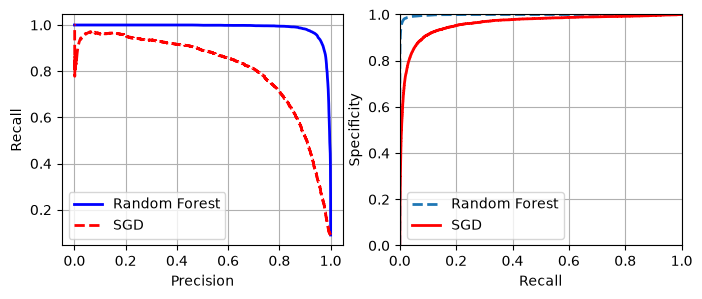

In [121]:
fig, axs = plt.subplots(1,2, figsize=(8,3))
axs[0].plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
axs[0].plot(recalls, precisions, "r--", linewidth=2, label="SGD")
axs[0].grid()
axs[0].set_xlabel('Precision')
axs[0].set_ylabel('Recall')

axs[1].plot(fpr_forest, tpr_forest, "--", linewidth=2, label="Random Forest")
axs[1].plot(fpr, tpr, "r-", linewidth=2, label="SGD")
axs[1].grid()
axs[1].set_xlabel("Recall")
axs[1].set_ylabel("Specificity")

plt.axis([0,1,0,1])
axs[0].legend(loc="lower left")
axs[1].legend(loc="lower left")

plt.show()

In [43]:
# Calculate f1_score, roc_auc and precision_average

y_train_pred_forest = y_probas_forest[:,1] >=0.5 #since the classifier returned probabilities not predictions and the positive is the second column
print("f1 score:", f1_score(y_train_5, y_train_pred_forest))
print()
print("roc_auc score:", roc_auc_score(y_train_5, y_scores_forest))
print()
print("average precision score:", average_precision_score(y_train_5, y_scores_forest))


f1 score: 0.9274509803921569

roc_auc score: 0.9983436731328145

average precision score: 0.98757633833578


In [44]:
recall_score(y_train_5, (y_scores_forest >= 0.5))

0.8725327430363402

# Multiclass (Multinomial) Classification

SGD Classifier, SVD are strictly binary classifiers  
RandomForest, LogisticRegression, GaussianNB are capable of handling multiple classes


_One versus the rest (OvR)_  
_One versus one (OvO)_

In [45]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2_000], y_train[:2000])  #we'll use only 2000 of the training set NOTE NOT y_train_5 so not binary

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [46]:
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [47]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

The svc classifier actually trained 45 binary OvO classifiers.  
Each of the 10 scores from the decision function is equal to the number of duels won plus or minus a small tweak to break ties.
The highest score is 9.3 (belonging to the digit 5)

In [48]:
some_digit_scores.argmax()

np.int64(5)

In [131]:
#The list of target classes is stored in its classes_ attribute ordered by value.
# Here the index of the each class conveniently matches the class itself i.e position 1 is the number 1
# But in general to lookup  the class you will need to do:
svm_clf.classes_[some_digit_scores.argmax()]

np.uint8(5)

In [132]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

Can force Scikit-Learn to use 0vO or OvR:

In [49]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[uint8](10,)","[0,1,2,...,7,8,9]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(random_state=42), SVC(random_state=42), SVC(random_state=42), SVC(random_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,784
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42


In [50]:
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [135]:
len(ovr_clf.estimators_)

10

In [51]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [138]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -19048.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

In [52]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")  #accuracy is fine since the numbers/classes are more or less uniformly distributed

array([0.87745, 0.85835, 0.8698 ])

We can improve accuracy by simply scaling the inputs with a StandardScaler

In [53]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

### Error Analysis (for multiclass)

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred= cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)


/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


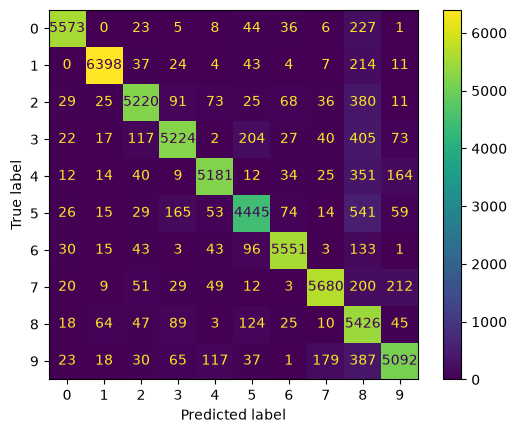

In [58]:

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

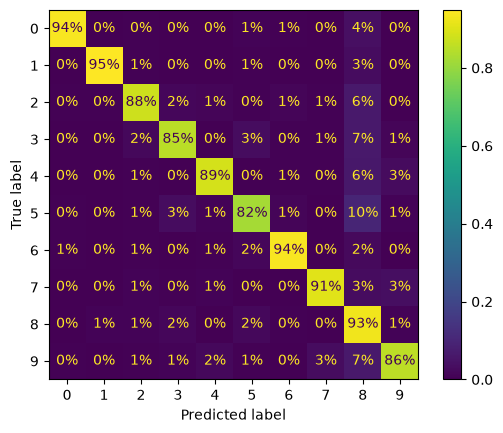

In [60]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true",
                             values_format=".0%"          )

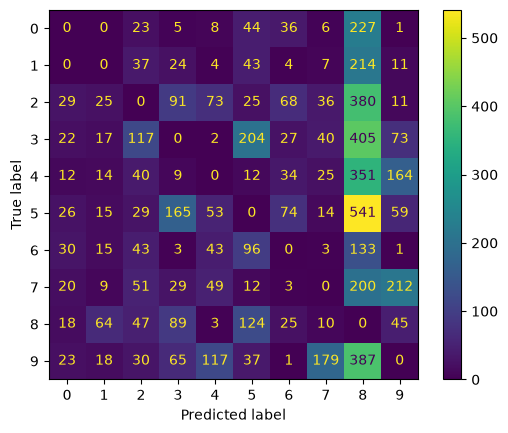

In [65]:
sample_weight= (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, 
        #sample_weight=sample_weight, normalize="true",values_format=".0%")
        sample_weight=sample_weight)
                                        

In [66]:
y_train_pred

array([3, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [75]:
X_ba = X_train[(y_train == 5) & (y_train_pred ==3)] 
                                    

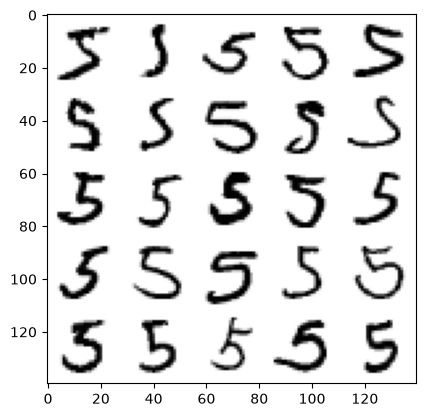

In [102]:
plt.imshow( X_ba[:25].reshape(5,5,28,28).transpose(0,2,1,3).reshape(5*28,5*28), cmap="binary")

# Multilabel Classification
Each instance can have multiple labels

In [112]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier",list,"[array([False, True]), array([False, True])]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [113]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [114]:
#Evaluate using F1 score: 
# we average over the f1 score for each binary classifier 

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [115]:
#If classes are unevenly distributed, give each label a weight
# equal to the number of instances of that label:
f1_score(y_multilabel, y_train_knn_pred, average="weighted")

0.9778357403921755

#### Chained multilabel classification
If we use a classifier that does not natively support multilabel classification  
we can train one model per label then use one model's prediction as an input feature in  
the next model

In [117]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,SVC()
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.",3
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.",None
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
Name,Type,Value
chain_method_ chain_method_: strPrediction method used by estimators in the chain for the predictionfeatures.,str,'predict'
classes_ classes_: listA list of arrays of length ``len(estimators_)`` containing theclass labels for each estimator in the chain.,list,"[array([False, True]), array([False, True])]"
estimators_ estimators_: listA list of clones of base_estimator.,list,"[SVC(), SVC()]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `base_estimator` exposes such an attribute when fit... versionadded:: 0.24,int,784


In [118]:
chain_clf.predict([some_digit])

array([[0., 1.]])

# Multioutput Classification 
multi-label classification where each label can be multiclass (i.e not just binary)

E.g lets take a noisy digit image and output a clean digit  
i.e Given an image (array of pixels) we will spit out multiple labels (one label per pixel) and each label can
range from 0 to 255

In [119]:
# Let's create the data set by adding noise to the MNIST images
rng= np.random.default_rng(seed=42)

noise_train = rng.integers(0,100, (len(X_train),784))
X_train_mod = X_train + noise_train
noise_test = rng.integers(0,100, (len(X_test), 784))
X_test_mod = X_test + noise_test
y_train_mod = X_train #we want the output to be the 'clean' initial data
y_test_mod = X_test

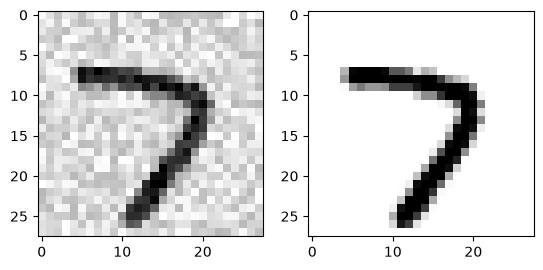

In [124]:
#image= image_data.reshape(28,28)
 #   plt.imshow(image, cmap="binary")
  #  plt.axis("off")

plt.subplot(121); plt.imshow(X_test_mod[17].reshape(28,28), cmap="binary")
plt.subplot(122); plt.imshow(X_test[17].reshape(28,28), cmap="binary")
plt.show()

Let's train the classifier to clean the image on the left

In [126]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)  #multioutput classification


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier",list,"[array([0]), array([0]), array([0]), array([0]), ...]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


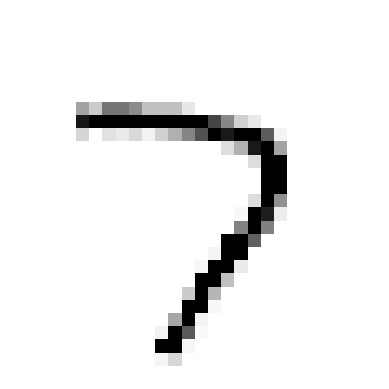

In [127]:
clean_digit = knn_clf.predict([X_test_mod[17]])
plot_digit(clean_digit)
plt.show()